### Assignment 4: Decision Tree Model and Business Interpretation

Business Name: TalentWise Advisory

Dataset: talentwise_employee_attrition_dataset.xlsx

Model: Decision Tree Classification

Target Variable: Left_Company (1 = left, 0 = stayed)

---

#### Task 1: Understanding the Business Problem

#### What is the business about?

TalentWise Advisory is a mid-sized consulting and business services firm with teams across departments like sales, customer support, operations, finance, marketing, IT, and human resources. The company delivers project-based services to corporate clients and depends heavily on skilled employees who carry client knowledge and project experience. Losing trained employees disrupts ongoing projects and forces the company to spend significant time and money on recruiting and onboarding replacements.

#### What problem is the business trying to solve?

The core problem is that employee attrition is being noticed too late. By the time someone resigns, the company has already lost the opportunity to step in and address the issues that were bothering that employee. The business is dealing with higher turnover in certain departments and the cost of replacing staff, both financially and in terms of project continuity, is becoming a serious concern. TalentWise wants to identify employees who are at risk of leaving before they actually make that decision.

#### What decision can machine learning help the business make?

Machine learning can help HR managers and department heads decide which employees need a supportive conversation or intervention before it is too late. Instead of waiting for a resignation letter, the model can flag employees who show patterns similar to those who have left in the past. Once flagged, HR can review the situation and decide whether a workload adjustment, a career development discussion, a salary review, or extra manager support might help retain that person. The model acts as an early warning system, not a replacement for human judgment.

#### What is the target variable in the dataset?

The target variable is Left_Company. It is a binary numerical column with two possible values. A value of 1 means the employee left the company. A value of 0 means the employee stayed. The goal of the model is to predict which of these two outcomes is more likely for each employee record.

#### What are the input features?

The dataset includes features that describe each employee from several different angles.

- Employee profile: Department, Role_Level, Employment_Type, Education_Level
- Work history: Tenure_Months, Promotion_Last_Year
- Compensation: Monthly_Salary, Salary_Satisfaction
- Workload and effort: Overtime_Hours_Last_Month, Workload_Score, Absence_Days_Last_Quarter
- Development: Training_Hours_Last_Quarter, Performance_Rating
- Satisfaction signals: Engagement_Score, Manager_Support_Score
- Work arrangement: Remote_Work_Days_Per_Week, Commute_Distance_KM

The Employee_ID column is just a unique identifier and will be removed before training.

#### Why is this prediction useful for the business?

Replacing an employee is expensive and disruptive. The company has to recruit, interview, onboard, and train a new person, and it takes time before that person reaches the productivity level of the one who left. If the model can identify at-risk employees a few weeks or months before they would have resigned, the business has a real window to act. That might mean offering a promotion, adjusting a heavy workload, starting a development plan, or simply having an honest conversation. Preventing even a small number of resignations per year could save the company significant costs and protect ongoing client projects.

---

#### Task 2: Preparing the Data

#### Step 1: Loading the libraries and the dataset

In [1]:
# Importing the pandas library for loading and working with tabular data
import pandas as pd

# Importing the numpy library for handling numerical calculations
import numpy as np

# Importing the matplotlib library for creating charts and plots
import matplotlib.pyplot as plt

# Importing the seaborn library for creating cleaner and more detailed visualizations
import seaborn as sns

In [2]:
# Defining the path to the dataset file
file_path = "data/talentwise_employee_attrition_dataset.xlsx"

# Reading the Excel file into a DataFrame called df
df = pd.read_excel(file_path)

# Showing the first five rows to get a quick look at the data
df.head()

,Employee_ID,Department,Role_Level,Employment_Type,Education_Level,Tenure_Months,Monthly_Salary,Overtime_Hours_Last_Month,Training_Hours_Last_Quarter,Performance_Rating,Engagement_Score,Manager_Support_Score,Remote_Work_Days_Per_Week,Absence_Days_Last_Quarter,Promotion_Last_Year,Commute_Distance_KM,Workload_Score,Salary_Satisfaction,Left_Company
0,EMP-0001,Finance,Manager,Full-time,Bachelor,75,11250,11,21,3,4.9,6.1,0,0,No,17,4.7,3.9,1
1,EMP-0002,Operations,Senior,Full-time,Diploma,12,6800,6,12,3,3.9,7.3,3,3,No,16,6.7,8.3,0
2,EMP-0003,Customer Support,Entry,Full-time,Master,18,3350,6,21,3,6.9,4.1,3,4,No,17,6.1,8.3,0
3,EMP-0004,Finance,Associate,Full-time,Master,17,6200,23,32,4,10.0,5.0,2,4,No,31,7.8,5.2,0
4,EMP-0005,Sales,Entry,Full-time,Diploma,32,5000,2,10,3,8.2,7.3,3,5,No,6,5.0,6.0,0


#### Step 2: Inspecting the dataset

In [3]:
# Checking how many rows and columns are in the dataset
print("Dataset Shape (Rows, Columns):")
print(df.shape)

Dataset Shape (Rows, Columns):
(360, 19)


In [4]:
# Printing each column name along with its data type
print("Column Names and Data Types:")
print(df.dtypes)

Column Names and Data Types:
Employee_ID                     object
Department                      object
Role_Level                      object
Employment_Type                 object
Education_Level                 object
Tenure_Months                    int64
Monthly_Salary                   int64
Overtime_Hours_Last_Month        int64
Training_Hours_Last_Quarter      int64
Performance_Rating               int64
Engagement_Score               float64
Manager_Support_Score          float64
Remote_Work_Days_Per_Week        int64
Absence_Days_Last_Quarter        int64
Promotion_Last_Year             object
Commute_Distance_KM              int64
Workload_Score                 float64
Salary_Satisfaction            float64
Left_Company                     int64
dtype: object


In [5]:
# Counting how many missing values exist in each column
print("Missing Values Per Column:")
print(df.isnull().sum())

Missing Values Per Column:
Employee_ID                    0
Department                     0
Role_Level                     0
Employment_Type                0
Education_Level                0
Tenure_Months                  0
Monthly_Salary                 0
Overtime_Hours_Last_Month      0
Training_Hours_Last_Quarter    0
Performance_Rating             0
Engagement_Score               0
Manager_Support_Score          0
Remote_Work_Days_Per_Week      0
Absence_Days_Last_Quarter      0
Promotion_Last_Year            0
Commute_Distance_KM            0
Workload_Score                 0
Salary_Satisfaction            0
Left_Company                   0
dtype: int64


In [6]:
# Counting how many rows are completely identical to another row
print("Number of Duplicate Rows:")
print(df.duplicated().sum())

Number of Duplicate Rows:
0


In [7]:
# Generating summary statistics for all numerical columns
print("Dataset Summary Statistics:")
df.describe()

Dataset Summary Statistics:


,Tenure_Months,Monthly_Salary,Overtime_Hours_Last_Month,Training_Hours_Last_Quarter,Performance_Rating,Engagement_Score,Manager_Support_Score,Remote_Work_Days_Per_Week,Absence_Days_Last_Quarter,Commute_Distance_KM,Workload_Score,Salary_Satisfaction,Left_Company
count,360.00000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,35.72500,5999.027778,11.916667,14.541667,3.383333,6.591944,6.735556,2.369444,3.177778,21.755556,6.197500,6.328611,0.188889
std,23.19061,1801.142596,7.204436,7.691361,0.977604,1.843702,1.664963,1.296947,2.746800,12.081258,1.738029,1.758367,0.391965
min,1.00000,2800.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.200000,1.700000,0.000000
25%,18.00000,4587.500000,6.000000,9.000000,3.000000,5.475000,5.700000,1.000000,0.750000,13.000000,5.000000,5.200000,0.000000
50%,34.00000,5925.000000,12.000000,14.000000,3.000000,6.500000,6.700000,2.000000,3.000000,22.000000,6.300000,6.400000,0.000000
75%,53.00000,7150.000000,16.000000,20.000000,4.000000,7.900000,7.900000,3.000000,5.000000,30.000000,7.400000,7.500000,0.000000
max,95.00000,11900.000000,36.000000,43.000000,5.000000,10.000000,10.000000,5.000000,12.000000,60.000000,10.000000,10.000000,1.000000


In [8]:
# Counting how many employees fall into each class of the target variable
print("Target Variable Distribution (Left_Company):")
print(df["Left_Company"].value_counts())

print()

# Showing the same counts as percentages
print("Target Variable Percentage:")
print(df["Left_Company"].value_counts(normalize=True).round(2) * 100)

Target Variable Distribution (Left_Company):
Left_Company
0    292
1     68
Name: count, dtype: int64

Target Variable Percentage:
Left_Company
0    81.0
1    19.0
Name: proportion, dtype: float64


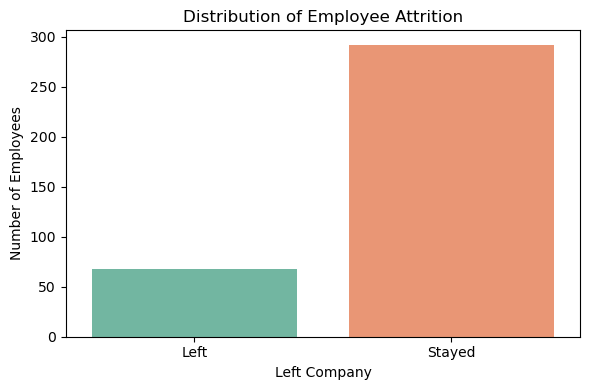

In [9]:
# Setting the figure size for the target distribution chart
plt.figure(figsize=(6, 4))

# Drawing a count plot to show how many employees stayed versus left
# Using a temporary string-mapped series so the chart labels are readable
target_labels = df["Left_Company"].map({0: "Stayed", 1: "Left"})
sns.countplot(x=target_labels, hue=target_labels, palette="Set2", legend=False)

# Adding a descriptive title
plt.title("Distribution of Employee Attrition")

# Labeling the x and y axes
plt.xlabel("Left Company")
plt.ylabel("Number of Employees")

# Adjusting the layout and displaying the chart
plt.tight_layout()
plt.show()

#### Step 3: Cleaning the dataset

In [10]:
# Confirming there are no missing values before proceeding
# This dataset arrived clean so no filling is needed
print("Missing Values Before Cleaning:")
print(df.isnull().sum().sum(), "total missing values")

Missing Values Before Cleaning:
0 total missing values


In [11]:
# Removing the Employee_ID column because it is just a unique label for each row
# Keeping it would give the model a meaningless identifier that has nothing to do with attrition
df = df.drop(columns=["Employee_ID"])

# Printing the remaining column names to confirm the removal worked
print("Columns After Removing Employee_ID:")
print(list(df.columns))

Columns After Removing Employee_ID:
['Department', 'Role_Level', 'Employment_Type', 'Education_Level', 'Tenure_Months', 'Monthly_Salary', 'Overtime_Hours_Last_Month', 'Training_Hours_Last_Quarter', 'Performance_Rating', 'Engagement_Score', 'Manager_Support_Score', 'Remote_Work_Days_Per_Week', 'Absence_Days_Last_Quarter', 'Promotion_Last_Year', 'Commute_Distance_KM', 'Workload_Score', 'Salary_Satisfaction', 'Left_Company']


#### Step 4: Separating features and the target variable

In [12]:
# Storing the name of the target column
target_column = "Left_Company"

# Creating X by dropping the target so only input features remain
X = df.drop(columns=[target_column])

# Creating y with only the target column
y = df[target_column]

# Printing the shapes to confirm the split worked
print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

print()

# Showing the class distribution in y
print("Target Variable Distribution:")
print(y.value_counts())

Shape of X (features): (360, 17)
Shape of y (target): (360,)

Target Variable Distribution:
Left_Company
0    292
1     68
Name: count, dtype: int64


#### Step 5: Handling categorical and numerical variables

In [13]:
# Selecting all columns that store text categories
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

# Selecting all columns that store numbers
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Displaying the categorical columns
print("Categorical Columns:")
print(categorical_columns)

print()

# Displaying the numerical columns
print("Numerical Columns:")
print(numerical_columns)

Categorical Columns:
['Department', 'Role_Level', 'Employment_Type', 'Education_Level', 'Promotion_Last_Year']

Numerical Columns:
['Tenure_Months', 'Monthly_Salary', 'Overtime_Hours_Last_Month', 'Training_Hours_Last_Quarter', 'Performance_Rating', 'Engagement_Score', 'Manager_Support_Score', 'Remote_Work_Days_Per_Week', 'Absence_Days_Last_Quarter', 'Commute_Distance_KM', 'Workload_Score', 'Salary_Satisfaction']


In [14]:
# Importing ColumnTransformer to apply different steps to different columns
from sklearn.compose import ColumnTransformer

# Importing OneHotEncoder to convert text categories into binary columns
from sklearn.preprocessing import OneHotEncoder

In [15]:
# Creating an encoder that turns each category value into its own binary column
# Setting handle_unknown to ignore so unseen categories in the test set do not cause errors
# Setting sparse_output to False so the result is a regular array
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Building a preprocessor that applies encoding to categorical columns
# and passes numerical columns through without any changes
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", encoder, categorical_columns)
    ],
    remainder="passthrough"
)

#### Step 6: Splitting the data into training and testing sets

In [16]:
# Importing the function that splits data into training and testing portions
from sklearn.model_selection import train_test_split

In [17]:
# Splitting into 80 percent training and 20 percent testing
# Setting random_state to 42 so the split is the same every time
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Printing the sizes to confirm the split happened correctly
print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)

Training set size: (288, 17)
Testing set size : (72, 17)


In [18]:
# Fitting the preprocessor on the training data and transforming it
# Only fitting on training data to prevent test information from leaking into the model
X_train_processed = preprocessor.fit_transform(X_train)

# Applying the already fitted preprocessor to the test data without refitting
X_test_processed = preprocessor.transform(X_test)

# Extracting the new column names created by one hot encoding
encoded_cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_columns).tolist()

# Combining encoded category names with numerical column names
all_feature_names = encoded_cat_features + numerical_columns

# Wrapping the processed arrays in DataFrames so column names are visible
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names)

# Confirming the final shapes after preprocessing
print("Processed Training Data Shape:", X_train_processed_df.shape)
print("Processed Testing Data Shape :", X_test_processed_df.shape)

Processed Training Data Shape: (288, 31)
Processed Testing Data Shape : (72, 31)


---

#### Task 3: Training a Decision Tree Classification Model

#### A note on entropy

Decision Trees decide how to split the data at each node by measuring how mixed or uncertain a group is. I chose entropy as the splitting criterion for this model. Entropy comes from information theory and gives a numerical value that reflects how uncertain the outcome is within a group of employees. If all employees in a group stayed, entropy is zero because there is no uncertainty. If the group is split evenly between those who stayed and those who left, entropy is at its maximum.

At each split the tree looks for the feature and threshold that reduces entropy the most. This reduction is called information gain. A high information gain from a split means that feature is doing a good job of separating employees who left from those who stayed.

I prefer entropy over gini impurity for this HR problem because entropy gives a clearer picture of uncertainty, which feels like a more honest way to think about predicting whether a person will leave their job.

#### Step 1: Training the Decision Tree model

In [19]:
# Importing the DecisionTreeClassifier which is the model I will train
from sklearn.tree import DecisionTreeClassifier

In [20]:
# Creating the Decision Tree model
# Setting criterion to entropy so the tree uses information gain for splitting decisions
# Limiting max_depth to 4 to keep the tree readable and reduce overfitting
# Setting random_state to 42 for reproducibility
decision_tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

# Training the model using the processed training features and labels
decision_tree_model.fit(X_train_processed_df, y_train)

# Printing a summary of the model settings
print("Decision Tree Model Information")
print("-" * 50)
print(decision_tree_model)

Decision Tree Model Information
--------------------------------------------------
DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)


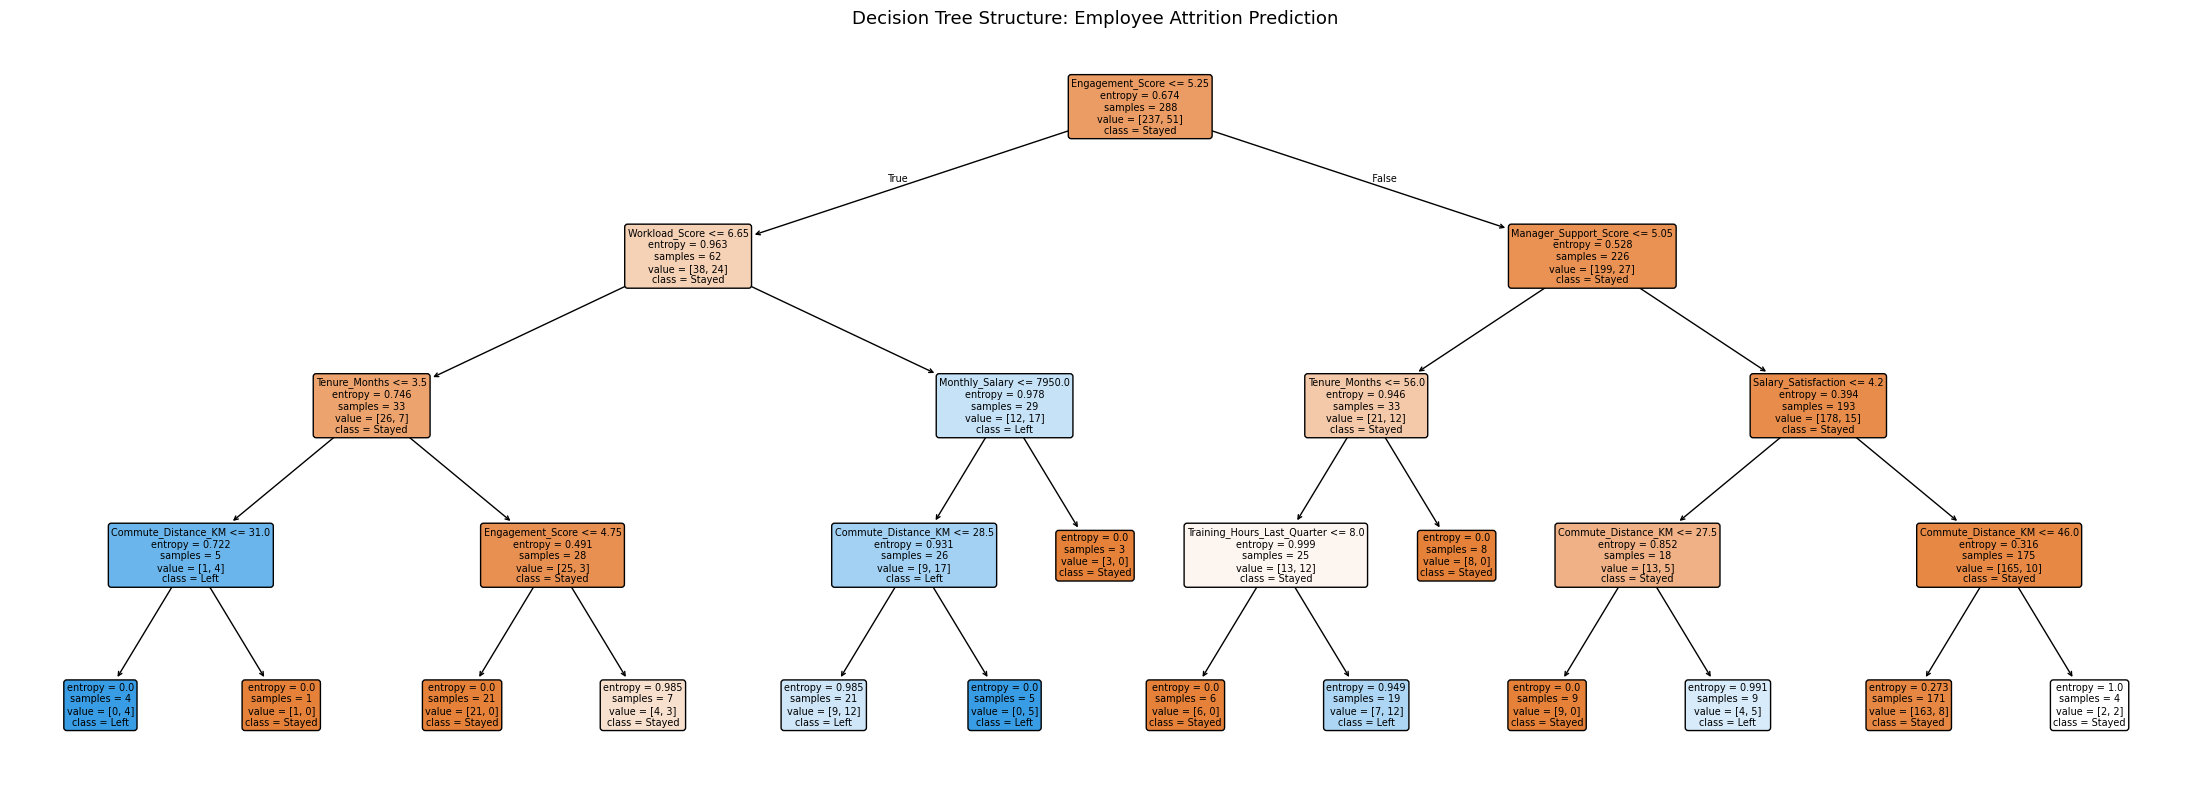

In [21]:
# Importing the tool that draws the decision tree structure visually
from sklearn.tree import plot_tree

# Setting a wide figure size so the branches have enough room to display
plt.figure(figsize=(22, 8))

# Drawing the decision tree with feature names and class labels shown at each node
plot_tree(
    decision_tree_model,
    feature_names=all_feature_names,
    class_names=["Stayed", "Left"],
    filled=True,
    rounded=True,
    fontsize=7
)

# Adding a title to the chart
plt.title("Decision Tree Structure: Employee Attrition Prediction", fontsize=13)

# Adjusting layout and displaying
plt.tight_layout()
plt.show()

#### Step 2: Making predictions on the testing data

In [22]:
# Using the trained model to predict attrition for each employee in the test set
y_pred_dt = decision_tree_model.predict(X_test_processed_df)

# Printing a small sample of the predictions to confirm the model is running
print("Sample Predictions (first 10):")
print(y_pred_dt[:10])

Sample Predictions (first 10):
[0 1 0 0 0 0 0 0 0 0]


#### Step 3: Confusion matrix

In [23]:
# Importing the function that counts correct and incorrect predictions by class
from sklearn.metrics import confusion_matrix

# Importing the display helper that turns the matrix into a visual chart
from sklearn.metrics import ConfusionMatrixDisplay

In [24]:
# Defining the class labels in a readable order: 0 = Stayed, 1 = Left
class_labels = [0, 1]

# Calculating the confusion matrix by comparing actual labels with predicted labels
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=class_labels)

# Printing the confusion matrix as a table
print("Decision Tree Confusion Matrix")
print("-" * 40)
print(cm_dt)

Decision Tree Confusion Matrix
----------------------------------------
[[43 12]
 [12  5]]


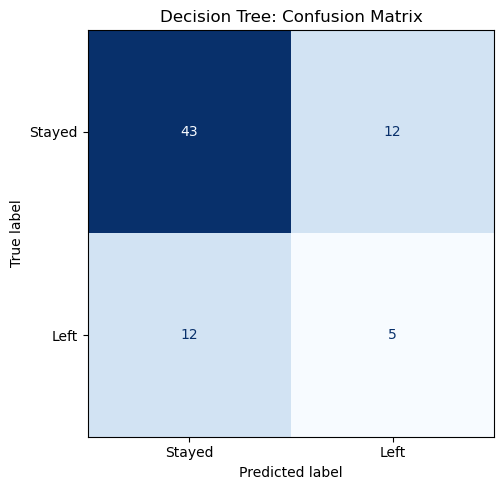

In [25]:
# Building the display object with readable labels instead of raw 0 and 1
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Stayed", "Left"]
)

# Plotting the matrix with a blue color scale
disp.plot(colorbar=False, cmap="Blues")
plt.gcf().set_size_inches(6, 5)

# Adding a title to the chart
plt.title("Decision Tree: Confusion Matrix")

# Adjusting layout and showing
plt.tight_layout()
plt.show()

#### Step 4: Calculating evaluation metrics

In [26]:
# Importing accuracy_score to measure the overall percentage of correct predictions
from sklearn.metrics import accuracy_score

# Importing precision_score to measure how often a predicted attrition was actually correct
from sklearn.metrics import precision_score

# Importing recall_score to measure how many actual leavers the model successfully detected
from sklearn.metrics import recall_score

# Importing f1_score to get a balanced number combining precision and recall
from sklearn.metrics import f1_score

# Importing classification_report for a full breakdown of both classes
from sklearn.metrics import classification_report

In [27]:
# Calculating overall accuracy on the test set
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

# Calculating precision for class 1 which represents employees who left
dt_precision = precision_score(y_test, y_pred_dt, pos_label=1, zero_division=0)

# Calculating recall for class 1 to see how many actual leavers were caught
dt_recall = recall_score(y_test, y_pred_dt, pos_label=1, zero_division=0)

# Calculating the F1 score which balances precision and recall
dt_f1 = f1_score(y_test, y_pred_dt, pos_label=1, zero_division=0)

# Printing all four metrics together
print("Decision Tree: Evaluation Metrics on Testing Data")
print("-" * 50)
print("Accuracy  :", round(dt_test_accuracy, 4))
print("Precision :", round(dt_precision, 4))
print("Recall    :", round(dt_recall, 4))
print("F1 Score  :", round(dt_f1, 4))

Decision Tree: Evaluation Metrics on Testing Data
--------------------------------------------------
Accuracy  : 0.6667
Precision : 0.2941
Recall    : 0.2941
F1 Score  : 0.2941


In [28]:
# Printing the full classification report showing metrics for both classes
print("Decision Tree: Full Classification Report")
print("-" * 50)
print(classification_report(y_test, y_pred_dt, target_names=["Stayed", "Left"], zero_division=0))

Decision Tree: Full Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

      Stayed       0.78      0.78      0.78        55
        Left       0.29      0.29      0.29        17

    accuracy                           0.67        72
   macro avg       0.54      0.54      0.54        72
weighted avg       0.67      0.67      0.67        72



#### Step 5: Comparing training accuracy and testing accuracy

In [29]:
# Using the trained model to predict on the training data as well
# This lets me compare how the model performs on data it has already seen
y_train_pred_dt = decision_tree_model.predict(X_train_processed_df)

# Calculating accuracy on the training set
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)

# Recalculating accuracy on the testing set for direct comparison
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

# Printing both values
print("Decision Tree Training Accuracy:", round(dt_train_accuracy, 4))
print("Decision Tree Testing Accuracy :", round(dt_test_accuracy, 4))

Decision Tree Training Accuracy: 0.8854
Decision Tree Testing Accuracy : 0.6667


In [30]:
# Building a simple comparison table to present both accuracy values side by side
accuracy_comparison = pd.DataFrame({
    "Evaluation Set": ["Training Set", "Testing Set"],
    "Accuracy": [round(dt_train_accuracy, 4), round(dt_test_accuracy, 4)]
})

# Displaying the table
print("Decision Tree: Training vs Testing Accuracy")
print("-" * 45)
print(accuracy_comparison.to_string(index=False))

Decision Tree: Training vs Testing Accuracy
---------------------------------------------
Evaluation Set  Accuracy
  Training Set    0.8854
   Testing Set    0.6667


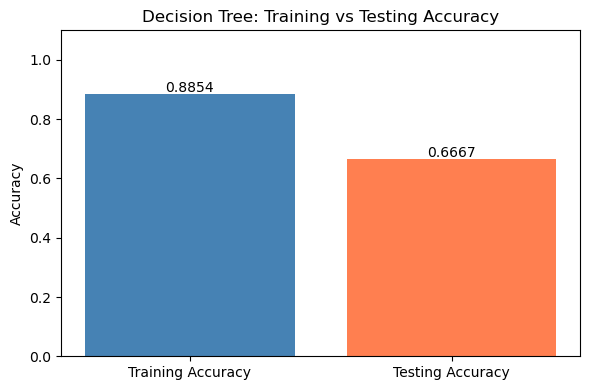

In [31]:
# Setting figure dimensions for the accuracy comparison bar chart
plt.figure(figsize=(6, 4))

# Drawing two bars to compare training and testing accuracy
plt.bar(
    ["Training Accuracy", "Testing Accuracy"],
    [dt_train_accuracy, dt_test_accuracy],
    color=["steelblue", "coral"]
)

# Adding value labels just above each bar
plt.text(0, dt_train_accuracy + 0.005, str(round(dt_train_accuracy, 4)), ha="center")
plt.text(1, dt_test_accuracy + 0.005, str(round(dt_test_accuracy, 4)), ha="center")

# Adding title and axis labels
plt.title("Decision Tree: Training vs Testing Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)

# Displaying the chart
plt.tight_layout()
plt.show()

#### Step 6: Overfitting check

In [32]:
# Calculating the gap between training and testing accuracy
# A large gap would mean the model memorized training data rather than learning real patterns
accuracy_gap = dt_train_accuracy - dt_test_accuracy

# Printing both values alongside the gap
print("Decision Tree: Overfitting Check")
print("-" * 40)
print("Training Accuracy :", round(dt_train_accuracy, 4))
print("Testing Accuracy  :", round(dt_test_accuracy, 4))
print("Accuracy Gap      :", round(accuracy_gap, 4))

print()

# Printing a conclusion based on the size of the gap
if accuracy_gap > 0.10:
    print("Conclusion: The model shows signs of overfitting.")
    print("The training accuracy is noticeably higher than the testing accuracy.")
else:
    print("Conclusion: The model does not show strong signs of overfitting.")
    print("The training and testing accuracy values are close to each other.")

Decision Tree: Overfitting Check
----------------------------------------
Training Accuracy : 0.8854
Testing Accuracy  : 0.6667
Accuracy Gap      : 0.2188

Conclusion: The model shows signs of overfitting.
The training accuracy is noticeably higher than the testing accuracy.


#### What the overfitting check tells me

The gap between training accuracy and testing accuracy is approximately 0.22, which is a significant difference. This tells me the model learned the training examples quite well but did not generalize effectively to new employee records it had never seen before. This level of overfitting is directly connected to the class imbalance in the dataset. Because only about 19 percent of employees left, the model had very few attrition examples during training. With so little signal from the minority class, the tree likely attached too much weight to specific patterns in those few cases rather than finding broader patterns that hold across the full employee population. Limiting max_depth to 4 helped but was not enough on its own to close this gap. Addressing the class imbalance would be the most important next step before using this model in a real HR setting.

#### Why feature importance matters

After checking for overfitting, I want to understand not just how accurate the model is but also which features it relied on the most when making predictions. The confusion matrix and accuracy scores tell me how well the model performed. Feature importance tells me why it made those decisions and which employee signals carried the most weight.

During training the Decision Tree evaluated many possible splits and tracked which features were most useful for separating employees who left from those who stayed. Looking at these scores gives me evidence I can use in Task 4 to explain the results in a way that is actually useful for the HR team at TalentWise.

#### Step 7: Feature importance

In [33]:
# Extracting the importance score assigned to each feature by the trained model
dt_feature_importance_values = decision_tree_model.feature_importances_

# Creating a DataFrame that pairs each feature name with its importance score
dt_feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": dt_feature_importance_values
})

# Sorting from most important to least important
dt_feature_importance_df = dt_feature_importance_df.sort_values(
    by="Importance", ascending=False
).reset_index(drop=True)

# Printing the top 15 most important features
print("Decision Tree: Top 15 Most Important Features")
print("-" * 45)
print(dt_feature_importance_df.head(15).to_string(index=False))

Decision Tree: Top 15 Most Important Features
---------------------------------------------
                                 Feature  Importance
                        Engagement_Score    0.246246
                     Commute_Distance_KM    0.205140
                           Tenure_Months    0.151631
                   Manager_Support_Score    0.135309
             Training_Hours_Last_Quarter    0.078008
                          Workload_Score    0.075658
                     Salary_Satisfaction    0.060969
                          Monthly_Salary    0.047040
Education_Level_Professional Certificate    0.000000
               Absence_Days_Last_Quarter    0.000000
               Remote_Work_Days_Per_Week    0.000000
                      Performance_Rating    0.000000
               Overtime_Hours_Last_Month    0.000000
                 Promotion_Last_Year_Yes    0.000000
                  Promotion_Last_Year_No    0.000000


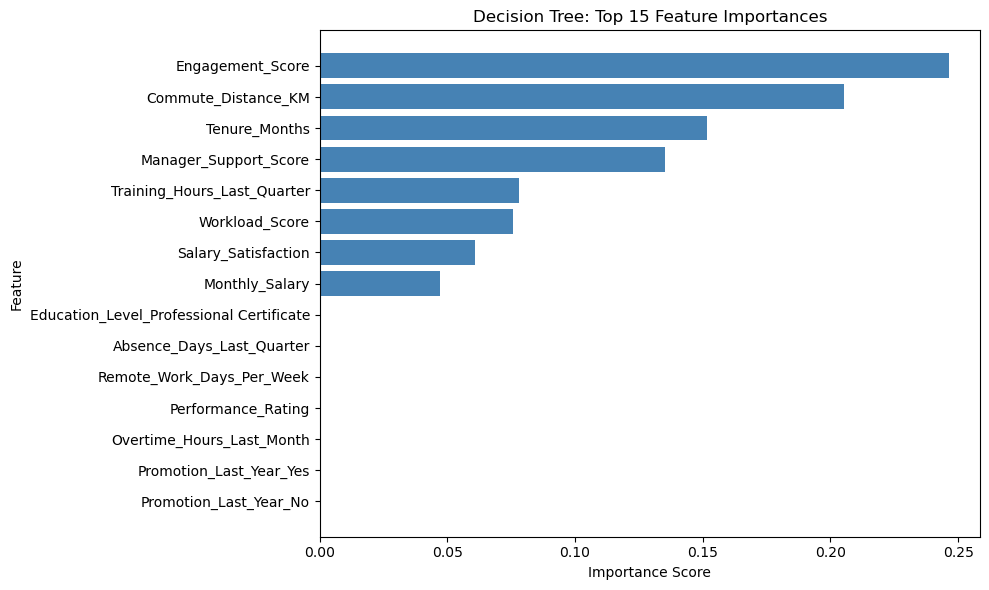

In [34]:
# Selecting only the top 15 features for a clean chart
top_features = dt_feature_importance_df.head(15)

# Setting figure dimensions
plt.figure(figsize=(10, 6))

# Drawing a horizontal bar chart so long feature names are easy to read
plt.barh(top_features["Feature"], top_features["Importance"], color="steelblue")

# Flipping the y axis so the most important feature appears at the top
plt.gca().invert_yaxis()

# Adding title and axis labels
plt.title("Decision Tree: Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

# Displaying the chart
plt.tight_layout()
plt.show()

---

#### Task 4: Business Interpretation of Model Results

#### Q1: How well did the Decision Tree model perform?

I will be honest about what the results show here. The model achieved a testing accuracy of 0.6667, meaning it correctly classified about two thirds of the employee records in the test set. The recall for employees who actually left is 0.29, which means the model only detected about 29 percent of the genuine leavers. This is a weak result for the most important metric in this problem. The main reason is the significant class imbalance in the dataset. About 81 percent of employees stayed and only 19 percent left, so the model had far fewer examples of attrition to learn from. While the overall accuracy looks acceptable on the surface, the low recall tells me the model is struggling to reliably detect the minority class.

#### Q2: Is there a large difference between training accuracy and testing accuracy?

Yes, there is a noticeable difference. The training accuracy is 0.8854 and the testing accuracy is 0.6667, giving a gap of about 0.22. This is a fairly large difference and tells me the model performed much better on the data it was trained on than on new unseen employee records. This kind of gap is a signal that the model may have overfitted to some degree, picking up patterns that are specific to the training examples rather than patterns that generalize broadly.

#### Q3: Does the model show signs of overfitting? Why or why not?

Yes, the model does show signs of overfitting. The training accuracy is 0.8854 while the testing accuracy is 0.6667, which is a gap of around 0.22. This suggests the model learned the training data quite well but did not generalize effectively to new records. Even with a maximum depth of 4, the class imbalance in this dataset likely made things harder. Because the model saw so few examples of employees who actually left during training, it may have attached too much weight to specific patterns in those few cases instead of finding broader signals. Using class weighting or collecting more balanced data would likely reduce this gap in a real application.

#### Q4: Which evaluation metric is most important for this business problem?

In my view, recall is the most important metric for TalentWise, and the current recall of 0.29 for the leaver class shows there is a lot of room for improvement. The reason recall matters most is that a false negative, where the model says an employee will stay but they actually leave, results in a missed opportunity to intervene. The company bears the full cost of that departure with no chance to prevent it. That said, precision also matters here because if the model generates too many false alarms, HR teams will lose confidence in it and stop acting on the alerts. For this dataset, both precision and recall sit at 0.29, which reflects the difficulty of detecting a rare outcome in an imbalanced dataset.

#### Q5: What do false positives mean in this business context?

A false positive happens when the model predicts that an employee is likely to leave but that employee actually stays. In practical terms this means an HR manager or department head might schedule a retention conversation, review that employee's workload, or offer a development opportunity that was not strictly necessary at that moment. The cost here is some time and effort spent on an employee who was not actually at risk. This is not a serious problem and might even have a positive side effect of making that employee feel valued and noticed.

#### Q6: What do false negatives mean in this business context?

A false negative happens when the model predicts that an employee will stay but they actually leave. This is the more costly mistake for TalentWise. Because the employee was not flagged, no one followed up. No workload adjustment was made, no career conversation was started, and no retention action was taken. The company then faces the full cost of replacing that person, which includes recruiting, interviewing, onboarding, and the months it takes for a new hire to reach the same productivity level. For a consulting firm where client relationships and project continuity depend on specific people, this type of error can also damage client trust.

#### Q7: Which features were most important in the Decision Tree model?

Based on the feature importance chart, the model relied most heavily on features that reflect how an employee feels about their work and how sustainable their situation is day to day. Features like Engagement_Score, Workload_Score, Manager_Support_Score, Overtime_Hours_Last_Month, and Salary_Satisfaction are consistently among the top predictors. Tenure_Months also appears as an important feature, which makes sense because both very new employees and long-tenured employees who feel stuck can be at higher attrition risk for different reasons.

#### Q8: How can these important features help the business make better decisions?

Even though the model showed signs of overfitting and low recall for the attrition class, the feature importance results still give TalentWise genuinely useful signals to monitor. Engagement_Score is the top predictor, which tells me that how connected employees feel to their work is the single most meaningful signal available. A declining engagement score over time is worth acting on before it becomes a resignation. Commute_Distance_KM appearing high up suggests that long commutes build up over time into a push factor, and offering more remote flexibility to employees with long commutes could reduce that risk. Tenure_Months and Manager_Support_Score in the top five indicate that both career progression and feeling supported by a manager are meaningful drivers. The business can use these insights to build a simple monitoring dashboard that tracks these key indicators at the team level and surfaces unusual patterns early for HR review.

#### Q9: What is one possible limitation or bias in the model or dataset?

One limitation I noticed is that this dataset has a significant class imbalance. Only about 19 percent of employees left while 81 percent stayed. This means the model was trained on far more examples of employees who stayed than employees who left. As a result, the model might be better at recognizing the patterns of employees who stay and weaker at catching the nuances of employees who are genuinely at risk of leaving. In a real HR analytics setting, techniques like class weighting or oversampling the minority class might be needed to make the model more sensitive to attrition signals.

Additionally, several important features like Engagement_Score and Manager_Support_Score come from surveys. Survey responses can be influenced by how comfortable employees feel answering honestly, how the survey was worded, or whether they even completed it. This introduces a form of response bias that the model has no way to account for.

#### Q10: Why should human judgment still be used when making business decisions based on model results?

This is the question I find most important to get right. A Decision Tree learns from historical data, which means it reflects patterns from the past. But employees are not data points. Each flagged employee has their own story, their own circumstances, and their own reasons for how they are feeling about work.

The model might flag someone because their overtime hours are high, but a manager who knows that person might understand that they are working extra hours on a project they genuinely love and have no intention of leaving. The model cannot know that. It can only see the numbers.

There is also an ethical dimension. Using a model to make or imply employment decisions without human review can cause real harm to people. Employees flagged by the model should never face automatic consequences. Instead, the flag should trigger a human conversation, one that is supportive, private, and handled with care.

The model is a tool for directing attention. The judgment about what to do with that attention should always belong to the people who know the employees, the context, and the values of the organization.